# Example session

In [1]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [ ]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgb, to_hex

from one.api import ONE
one = ONE(mode='remote')

In [4]:
data_path = prefix + 'representation_learning_variability/paper-individuality/1_segmentation/'
filename = str(data_path + 'all_sequences_23-03-2026')
filename = str(data_path + 'all_sequences_09-29-2025')
filename = str(data_path + 'all_sequences_26-03-2026')
all_sequences = pd.read_parquet(filename)

In [5]:
all_sequences['trial_id'] = all_sequences['sample'].str.split().str[1:2].str.join('').astype(float)
all_sequences['session'] = all_sequences['sample'].str.split().str[0:1].str.join('').astype(str)

In [46]:
identifiable_mapping = {'000': 0.0,
        '100': 1.0,
        '200': 2.0,
        '300': 3.0,
        '400': 4.0,
        '500': 5.0,
        '600': 6.0,
        '700': 7.0,
        
        '010': 8.0,
        '110': 9.0,
        '210': 10.0,
        '310': 11.0,
        '410': 12.0,
        '510': 13.0,
        '610': 14.0,
        '710': 15.0,

        '001': 16.0,
        '101': 17.0,
        '201': 18.0,
        '301': 19.0, 
        '401': 20.0, 
        '501': 21.0, 
        '601': 22.0, 
        '701': 23.0, 

        '011': 24.0,
        '111': 25.0,
        '211': 26.0,
        '311': 27.0,
        '411': 28.0,
        '511': 29.0,
        '611': 30.0,
        '711': 31.0,
        'nan': np.nan
        }

inverted_mapping = {v: k for k, v in identifiable_mapping.items()}
inverted_func = np.vectorize(inverted_mapping.get)
identifiable_func = np.vectorize(identifiable_mapping.get)

In [47]:
identifiable_mapping = {'000': 0.0,
        '100': 4.0,
        '200': 8.0,
        '300': 12.0,
        '400': 16.0,
        '500': 20.0,
        '600': 24.0,
        '700': 28.0,
        
        '010': 1.0,
        '110': 5.0,
        '210': 9.0,
        '310': 13.0,
        '410': 17.0,
        '510': 21.0,
        '610': 25.0,
        '710': 29.0,

        '001': 2.0,
        '101': 6.0,
        '201': 10.0,
        '301': 14.0, 
        '401': 18.0, 
        '501': 22.0, 
        '601': 26.0, 
        '701': 30.0, 

        '011': 3.0,
        '111': 7.0,
        '211': 11.0,
        '311': 15.0,
        '411': 19.0,
        '511': 23.0,
        '611': 27.0,
        '711': 31.0,
        'nan': np.nan
        }

# inverted_mapping = {v: k for k, v in identifiable_mapping.items()}
# inverted_func = np.vectorize(inverted_mapping.get)
identifiable_func = np.vectorize(identifiable_mapping.get)

In [119]:

# Get Set3 colors and exclude yellow (index 1) and grey (index 7)
set3_colors = sns.color_palette('Set3', n_colors=20)  # Get more colors to choose from
set3_no_yellow_grey = [color for i, color in enumerate(set3_colors) if i not in [1, 8, 9, 10]]
# Take first 8 colors from the filtered list
set3_filtered = set3_no_yellow_grey[:8]

def create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette=set3_filtered):
    # Pick n_groups distinct colors from base palette
    base_colors = sns.color_palette(base_palette, n_colors=n_groups)
    
    # Function to generate shades for a given color
    def generate_shades(color, n_shades):
        color_rgb = np.array(to_rgb(color))
        # Create shades by interpolating towards white (lighter) or black (darker)
        factors = np.linspace(0.5, 1.6, n_shades)  # You can adjust range for more/less contrast
        return [to_hex(color_rgb * factor + (1 - factor)) for factor in factors]
    
    # Build full palette
    full_palette = []
    for color in base_colors:
        shades = generate_shades(color, shades_per_group)
        full_palette.extend(shades)
    
    return ListedColormap(full_palette)

palette_16 = create_grouped_gradient_palette(n_groups=8, shades_per_group=4, base_palette=set3_filtered)


# Specific mice/ session

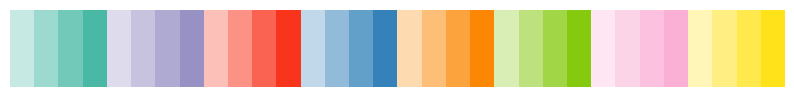

In [120]:
fig, ax = plt.subplots(figsize=(10, 1))
gradient = np.linspace(0, 1, palette_16.N).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=palette_16)
ax.set_axis_off()
# fig.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'palette_16.svg', format='svg', bbox_inches='tight')
plt.show()

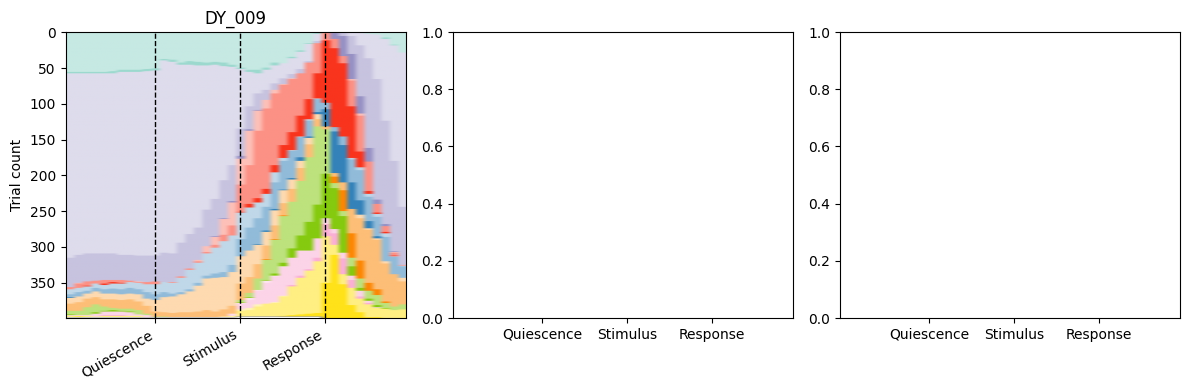

In [124]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=False, figsize=(12, 4))

epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
use_sequences = all_sequences.copy()
use_mice = ['PL033', 'PL033', 'UCLA037',  'NYU-30', 'NYU-48', 'PL034',  'ZFM-01936',  'NYU-45']
sessions = all_sequences['session'].unique()
for m, mouse in enumerate(sessions[1:2]):
    mouse_data = use_sequences.loc[use_sequences['session']==mouse]
    bound = int(np.shape(mouse_data)[0]/4)
    mouse_seq = np.ones((bound, 40)) * np.nan
    all_epochs = []
    for e, epoch in enumerate(epoch_to_analyse):
        epoch_data = np.vstack(mouse_data.loc[mouse_data['broader_label']==epoch, 'binned_sequence'].values)[:bound, :]
        epoch_data = inverted_func(epoch_data)
        # epoch_data = rename_func(epoch_data)
        epoch_data = identifiable_func(epoch_data)
        mouse_seq[:np.shape(epoch_data)[0], 10*e:10*e+10] = epoch_data[:np.shape(epoch_data)[0], :]

    axs[m].imshow(np.sort(mouse_seq, axis=0), aspect='auto', cmap=palette_16, interpolation=None, alpha=1)
    axs[m].axvline(x=10, color='k', linestyle='--', linewidth=1)
    axs[m].axvline(x=20, color='k', linestyle='--', linewidth=1)
    axs[m].axvline(x=30, color='k', linestyle='--', linewidth=1)
    axs[0].set_ylabel('Trial count')
    axs[m].set_xlabel('')
    mouse_name = use_sequences.loc[use_sequences['session']==mouse, 'mouse_name'].values[0]
    axs[m].set_title(mouse_name)
    axs[m].set_xticks(np.arange(10, 31, 10), ['Quiescence', 'Stimulus', 'Response'], rotation=30, ha='right')
    plt.tight_layout()
    fig.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'fig2_a.svg', format='svg', bbox_inches='tight')

## Trial type

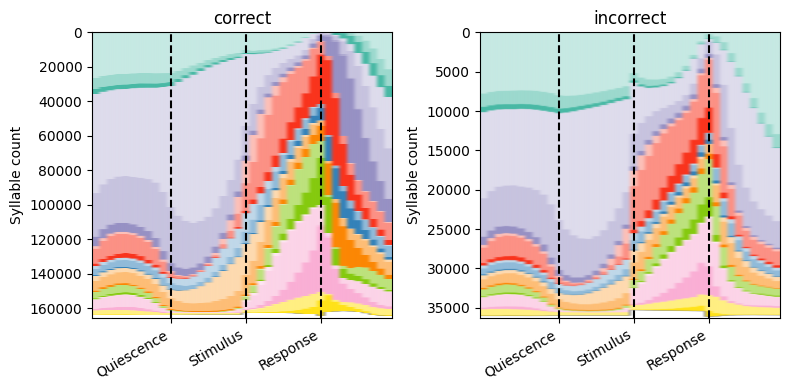

In [125]:
fig, axs = plt.subplots(1, 2, sharex=True, sharey=False, figsize=(8, 4))

epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
use_sequences = all_sequences.copy()

use_sequences['type'] = use_sequences['trial_type'].str.split().str[0:1].str.join('').astype(str)
types = np.sort(use_sequences['type'].unique())
# types = ['0.5', '0.2', '0.8']
for l, typ in enumerate(types):

        mouse_data = use_sequences.loc[use_sequences['type']==typ]
        bound = int(np.shape(mouse_data)[0]/4)
        mouse_seq = np.ones((bound, 40)) * np.nan
        all_epochs = []
        for e, epoch in enumerate(epoch_to_analyse):
            epoch_data = np.vstack(mouse_data.loc[mouse_data['broader_label']==epoch, 'binned_sequence'].values)[:bound, :]
            epoch_data = inverted_func(epoch_data)
            # epoch_data = rename_func(epoch_data)
            epoch_data = identifiable_func(epoch_data)
            mouse_seq[:np.shape(epoch_data)[0], 10*e:10*e+10] = epoch_data[:np.shape(epoch_data)[0], :]

        axs[l].imshow(np.sort(mouse_seq, axis=0), aspect='auto', cmap=palette_16, interpolation=None, alpha=1)
        axs[l].axvline(x=10, color='k', linestyle='--')
        axs[l].axvline(x=20, color='k', linestyle='--')
        axs[l].axvline(x=30, color='k', linestyle='--')
        axs[l].set_ylabel('Syllable count')
        axs[l].set_xlabel('')
        axs[l].set_title(typ)
        axs[l].set_xticks(np.arange(10, 31, 10), ['Quiescence', 'Stimulus', 'Response'], rotation=30, ha='right')
        plt.tight_layout()